# Audience Forecasting – Data Exploration

Loading the combined daily CSVs (`combined-csv/combined_YYYY-MM-DD.csv`) into pandas.
Each row is one minute of listener data for one station, joined to the show on air.
Timestamps are UTC.

### Project Imports

In [1]:
from pathlib import Path

from sklearn.tree import DecisionTreeClassifier
import pandas as pd
from prophet import Prophet
import statsmodels.api as sm
import matplotlib.pyplot as plt
import gc
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


### Find Data Directory

In [2]:
# Find the project root whether the kernel starts in workbook/ or the project folder
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "combined-csv").is_dir())
DATA_DIR = ROOT / "combined-csv"


### Init Data Import Functions

In [3]:
DATE_COLUMNS = ["timestamp", "show_start", "show_end"]


def load_day(day):
    file_path = DATA_DIR / f"combined_{day}.csv"
    if not file_path.exists():
        print(f'file for {day} does not exist. {file_path}')
        return None
    return pd.read_csv(file_path, parse_dates=DATE_COLUMNS)


def load_range(start, end):
    days = pd.date_range(start, end).strftime("%Y-%m-%d")
    dfs = [load_day(d) for d in days]
    dfs = [df for df in dfs if df is not None]
    return pd.concat(dfs, ignore_index=True)




### Simple check of data types, content and shape

In [4]:
df = load_day("2018-06-01")
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 11520 entries, 0 to 11519
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      11520 non-null  datetime64[us]
 1   current        11520 non-null  int64         
 2   show_start     11520 non-null  datetime64[us]
 3   show_end       11520 non-null  datetime64[us]
 4   show_title     6751 non-null   str           
 5   brand_title    11412 non-null  str           
 6   station        11520 non-null  str           
 7   broadcast_pid  11520 non-null  str           
 8   episode_pid    11520 non-null  str           
dtypes: datetime64[us](3), int64(1), str(5)
memory usage: 1.5 MB


,timestamp,current,show_start,show_end,show_title,brand_title,station,broadcast_pid,episode_pid
0,2018-06-01 00:00:00,224,2018-06-01,2018-06-01 02:00:00,Coldest from Mr Eazi,Radio 1's Soundsystem with Toddla T,bbc_1xtra,p0681psj,b0b3vg94
1,2018-06-01 00:01:00,222,2018-06-01,2018-06-01 02:00:00,Coldest from Mr Eazi,Radio 1's Soundsystem with Toddla T,bbc_1xtra,p0681psj,b0b3vg94
2,2018-06-01 00:02:00,223,2018-06-01,2018-06-01 02:00:00,Coldest from Mr Eazi,Radio 1's Soundsystem with Toddla T,bbc_1xtra,p0681psj,b0b3vg94
3,2018-06-01 00:03:00,220,2018-06-01,2018-06-01 02:00:00,Coldest from Mr Eazi,Radio 1's Soundsystem with Toddla T,bbc_1xtra,p0681psj,b0b3vg94
4,2018-06-01 00:04:00,220,2018-06-01,2018-06-01 02:00:00,Coldest from Mr Eazi,Radio 1's Soundsystem with Toddla T,bbc_1xtra,p0681psj,b0b3vg94


## Data Pre-processing

Load Train and Test data

In [5]:
df_train = load_range("2022-01-01", "2025-01-01")
df_test = load_range("2026-01-01", "2026-06-01")

# just look at radio one data for now
station_to_focus = 'bbc_radio_five_live'
df_train = df_train[df_train["station"] == station_to_focus]
df_train = df_test[df_test["station"] == station_to_focus]

Inspect ratio of Test to Train data

In [6]:
print(f'Ratio of test to train data: {(len(df_test)/len(df_train)):.2%}')

Ratio of test to train data: 1196.59%


Create functions for inspecting gaps in data

In [7]:
def find_missing(df):
    df = df.sort_values("timestamp")

    expected = pd.date_range(
        start=df["timestamp"].min(),
        end=df["timestamp"].max(),
        freq="1min"
    )

    missing = expected.difference(df["timestamp"])

    return missing

In [8]:
def find_gaps_per_station(df):
    df = df.sort_values(["station", "timestamp"]).copy()

    df["time_gap"] = (
        df.groupby("station")["timestamp"]
        .diff().dt.total_seconds() / 60
    ).astype('Int64')

    gaps = df[df["time_gap"] > 1][['timestamp', 'station', 'time_gap']]

    return gaps

In [9]:
missing = find_missing(df_train)
display(missing)

DatetimeIndex([], dtype='datetime64[us]', freq='min')

Forward Fill missing data

1. Sort
2. Prove gaps exist
3. Resample per station to create an entry for every minute (covering the missed entries)
4. Forward fill that missing data
5. Prove that missing data been filled

In [10]:
df_train_filled = df_train.copy()
df_train_filled.sort_values(["station", "timestamp"], inplace=True)


In [11]:
gaps = find_gaps_per_station(df_train_filled)
gaps.info()


<class 'pandas.DataFrame'>
Index: 0 entries
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  0 non-null      datetime64[us]
 1   station    0 non-null      str           
 2   time_gap   0 non-null      Int64         
dtypes: Int64(1), datetime64[us](1), str(1)
memory usage: 0.0 bytes


In [12]:
df_train_filled = (
    df_train_filled.set_index("timestamp")
    .groupby("station")
    .resample("1min")
    .asfreq()
    .reset_index()
)


In [13]:
cols = df_train_filled.columns.drop(["station", "timestamp"])
df_train_filled[cols] = df_train_filled.groupby("station")[cols].ffill()

In [14]:
#df.info()
#find_gaps_per_station(df_train)
#df.groupby("station").ffill()
#df.index.names
print(len(df_train_filled))
print(len(df_train))
#df_train_filled.groupby("station").ffill()
df_train_filled["current"].isna().sum()

# clean up no longer required df_train
del df_train
gc.collect()


218880
218880


18

In [15]:

find_gaps_per_station(df_train_filled)

,timestamp,station,time_gap


In [16]:
# Add further features to training data
def add_shifted_listener_data(_df, listeners_key='current'):
    for lag in [1, 5, 10, 15]:
        _df[f"listeners_{lag}_mins_ago"] = (
            _df.groupby("station")[listeners_key].shift(lag)
        )

add_shifted_listener_data(df_train_filled)


# Prophet Model

In [17]:
# Shape data to ds and y
df_prophet_train = df_train_filled.rename(columns={
    'timestamp': 'ds',
    'current': 'y'
})

# clean up no longer required df_train_filled
del df_train_filled
gc.collect()


df_prophet_train.columns

Index(['station', 'ds', 'y', 'show_start', 'show_end', 'show_title',
       'brand_title', 'broadcast_pid', 'episode_pid', 'listeners_1_mins_ago',
       'listeners_5_mins_ago', 'listeners_10_mins_ago',
       'listeners_15_mins_ago'],
      dtype='str')

In [18]:
prophet_models = {}
def create_prophet_by_station(_df, _station):
    print(f'+ Create Prophet Model for Station {_station}')
    prophet_model = Prophet()
    df_station = _df[_df['station'] == _station]
    prophet_model.fit(df_station)
    prophet_models[_station] = prophet_model
    print(f'- Created Prophet Model for Station {_station}')
    del df_station
    gc.collect()
# Loop through each station and create prophet model
for station in df_prophet_train['station'].unique():
    create_prophet_by_station(df_prophet_train, station)


print(prophet_models.keys())

+ Create Prophet Model for Station bbc_radio_five_live


17:07:33 - cmdstanpy - INFO - Chain [1] start processing
17:07:52 - cmdstanpy - INFO - Chain [1] done processing


- Created Prophet Model for Station bbc_radio_five_live
dict_keys(['bbc_radio_five_live'])


In [19]:
prophet_forecasts = {}
for station in prophet_models.keys():
    prophet = prophet_models[station]

    predict_dates = df_test[df_test["station"] == station]['timestamp']
    print(f'Count of timestamps for station "{station}": {len(predict_dates)}')
    df_predict_dates = predict_dates.sort_values().to_frame('ds')

    predictions = prophet.predict(df_predict_dates)
    prophet_forecasts[station] = predictions

    del df_predict_dates, predict_dates
    gc.collect()

Count of timestamps for station "bbc_radio_five_live": 218880


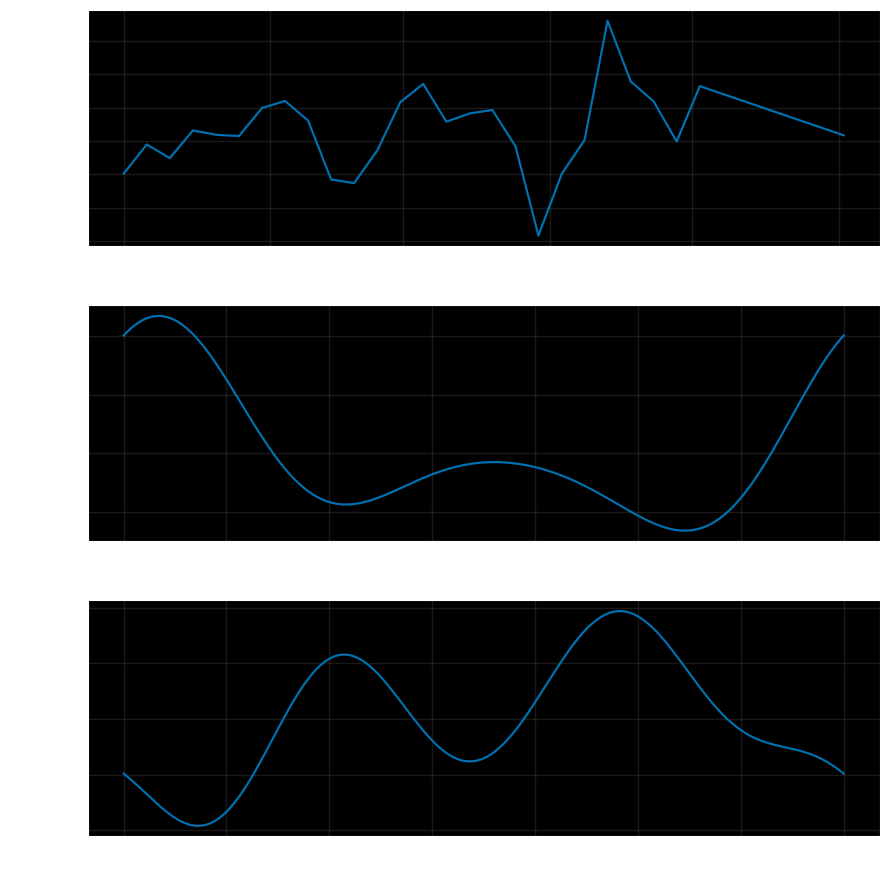

In [20]:
# For simple testing - Get just the first station that we have logged
for station in prophet_forecasts.keys():
    prophet_models[station].plot_components(
        prophet_forecasts[station]
    )

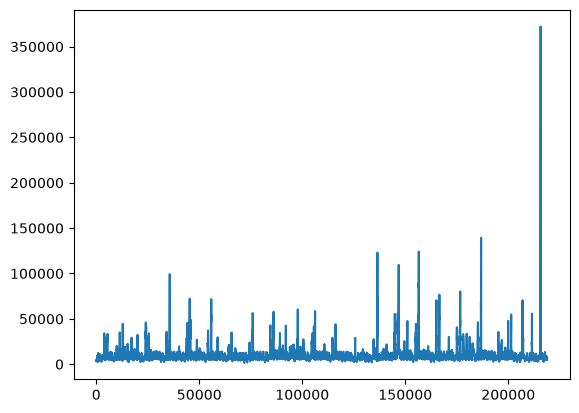

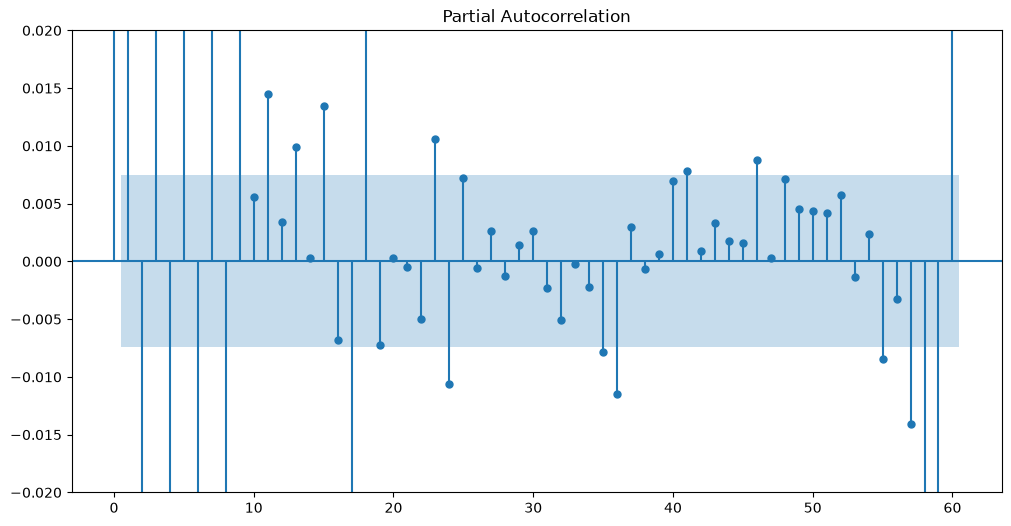

In [21]:
plt.style.use("default")
for station in prophet_forecasts.keys():
    df_training = df_prophet_train[df_prophet_train['station'] == station]
    df_training['y'].plot()
    fig, ax = plt.subplots(figsize=(12, 6))
    sm.graphics.tsa.plot_pacf(df_training['y'],
        lags=60,
        alpha=0.0005,
        ax=ax
    )

    ax.set_facecolor("white")
    fig.set_facecolor("white")
    ax.set_ylim(-0.02, 0.02)
    plt.show()
    plt.close()
    del df_training
    gc.collect()

                              y  listeners_1_mins_ago  listeners_5_mins_ago  \
y                      1.000000              0.998696              0.981298   
listeners_1_mins_ago   0.998696              1.000000              0.986543   
listeners_5_mins_ago   0.981298              0.986543              1.000000   
listeners_10_mins_ago  0.952672              0.958503              0.981298   
listeners_15_mins_ago  0.924672              0.930077              0.952672   

                       listeners_10_mins_ago  listeners_15_mins_ago  
y                                   0.952672               0.924672  
listeners_1_mins_ago                0.958503               0.930077  
listeners_5_mins_ago                0.981298               0.952672  
listeners_10_mins_ago               1.000000               0.981298  
listeners_15_mins_ago               0.981298               1.000000  
<class 'pandas.DataFrame'>
Index: 10000 entries, 128012 to 122565
Data columns (total 15 columns):
 #   C

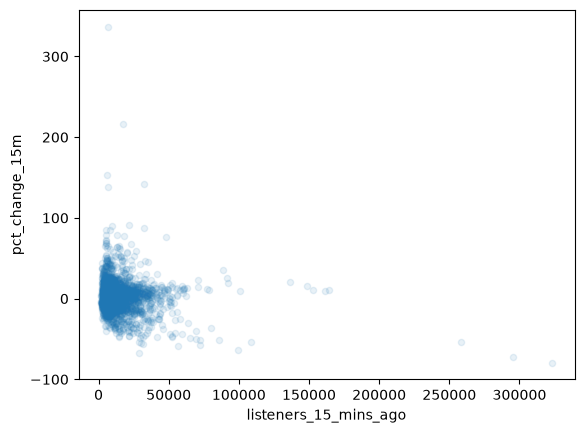

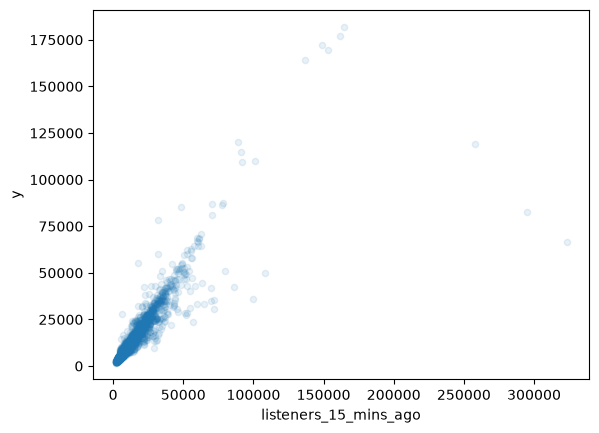

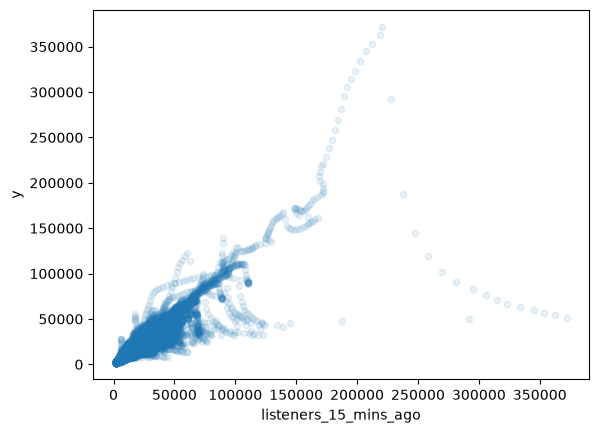

In [33]:
for station in prophet_forecasts.keys():
    sample = df_prophet_train[df_prophet_train['station'] == station].sample(10000, random_state=42)

    sample["pct_change_15m"] = (
        (sample["y"] - sample["listeners_15_mins_ago"])
        / sample["listeners_15_mins_ago"]
    ) * 100
    sample.plot.scatter(
        x="listeners_15_mins_ago",
        y="pct_change_15m",
        alpha=0.1
    )
    sample.plot.scatter(
        x="listeners_15_mins_ago",
        y="y",
        alpha=0.1
    )

    df_prophet_train.plot.scatter(
        x="listeners_15_mins_ago",
        y="y",
        alpha=0.1
    )

    cols = [
        "y",
        "listeners_1_mins_ago",
        "listeners_5_mins_ago",
        "listeners_10_mins_ago",
        "listeners_15_mins_ago"
    ]

    print(df_prophet_train[cols].corr())

    print(sample.info())

A strong correlation between listeners 15 minutes ago and now may make this task not very useful for ML?

Instead we could identify anomalies

In [23]:
# we can't trawl through the millions of rows of data to identify actual anomalies, instead mark the ones we suspect are
def add_anomaly_detection(_df, listeners_key='current'):
    grouped = _df.groupby("station")[listeners_key]
    rolling_mean = grouped.transform(
        lambda x: x.rolling(60).mean()
    )
    rolling_std = grouped.transform(
        lambda x: x.rolling(60).std()
    )
    z_score = (
            (_df[listeners_key] - rolling_mean)
            / rolling_std
    )
    _df["anomaly"] = z_score.abs() > 3

add_anomaly_detection(df_prophet_train, 'y')

In [24]:

category_columns = ['station', 'brand_title']
y_train = df_prophet_train['anomaly']
X_train = df_prophet_train.drop('anomaly', axis=1)

def add_time_features(df):
    df = df.copy()

    df["hour"] = df["ds"].dt.hour
    df["minute"] = df["ds"].dt.minute
    df["day_of_week"] = df["ds"].dt.dayofweek

    return df


time_features = FunctionTransformer(add_time_features)

column_preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore"), category_columns),
    (
        "passthrough",
        ["hour", "minute", "day_of_week", "y"]
    ),
    remainder="drop"
)

pipeline = make_pipeline(
    time_features,
    column_preprocessor,
    DecisionTreeClassifier(random_state=77)
)
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('functiontransformer', ...), ('columntransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['station','ds','y',...,'listeners_5_mins_ago','listeners_10_mins_ago', 'listeners_15_mins_ago']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...t 0x1399d8040>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False


In [25]:
df_test = df_test.rename(columns={
    'timestamp': 'ds',
    'current': 'y'
})

# Create the "true" anomaly labels in test data
add_anomaly_detection(df_test, listeners_key='y')

X_test = df_test.drop("anomaly", axis=1)
y_test = df_test["anomaly"]
# Predict

y_test_pred = pipeline.predict(X_test)

In [26]:

# Print scores
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1:", f1_score(y_test, y_test_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification report:")
print(classification_report(y_test, y_test_pred))


Accuracy: 0.9517537847823705
Precision: 0.0759533278155722
Recall: 0.17773631253247674
F1: 0.1064266116029757

Confusion matrix:
[[2485220   91549]
 [  34813    7525]]

Classification report:
              precision    recall  f1-score   support

       False       0.99      0.96      0.98   2576769
        True       0.08      0.18      0.11     42338

    accuracy                           0.95   2619107
   macro avg       0.53      0.57      0.54   2619107
weighted avg       0.97      0.95      0.96   2619107

